# Stock Price Prediction using HMM, LSTM, ARIMA, and RNN

In this notebook, we will predict stock prices using various methods including Hidden Markov Model (HMM), Long Short-Term Memory (LSTM), AutoRegressive Integrated Moving Average (ARIMA), and Recurrent Neural Network (RNN). We will compare the performance of these models using various error metrics.


In [44]:
# Import necessary libraries for data manipulation, model building, and evaluation
%matplotlib inline
from hmmlearn import hmm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import math
import scipy.stats as stats
import statsmodels.api as sm
# import gdown
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import SimpleRNN, LSTM, Dense
#from sklearn.preprocessing import MinMaxScaler
#from statsmodels.tsa.arima.model import ARIMA
#from sklearn.metrics import mean_squared_error


## Load and Prepare Data

In this section, we load the NIFTY 50 data and preprocess it for modeling.


In [45]:
data_csv = pd.read_csv(r"NIFTY 50.csv")

data = data_csv[data_csv.columns[0:5]]
data = data[:5348]

# Convert 'Date' column to datetime type
data['Date'] = pd.to_datetime(data['Date'])

# Set the 'Date' column as the index
data.set_index('Date', inplace=True)

# Resample the data to monthly frequency
obs = data.resample('M').agg({'Open': 'first','High': 'max','Low': 'min','Close': 'last'})

# Reset the index to have 'Date' as a column again
#obs = obs.reset_index()

# Print the monthly data
#print(obs)

##data = obs[:162]
#print(data)

/var/folders/yw/gbklf6sd5q3_sr89rbjcfv7w0000gn/T/ipykernel_29341/4148058189.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  obs = data.resample('M').agg({'Open': 'first','High': 'max','Low': 'min','Close': 'last'})


In [46]:
obs = data.copy()

obs = obs.reset_index()
data = obs[:162]
print(data)

          Date     Open     High      Low    Close
0   2000-01-03  1482.15  1592.90  1482.15  1592.20
1   2000-01-04  1594.40  1641.95  1594.40  1638.70
2   2000-01-05  1634.55  1635.50  1555.05  1595.80
3   2000-01-06  1595.80  1639.00  1595.80  1617.60
4   2000-01-07  1616.60  1628.25  1597.20  1613.30
..         ...      ...      ...      ...      ...
157 2000-08-18  1342.00  1360.65  1339.05  1358.05
158 2000-08-21  1358.75  1374.50  1358.75  1370.25
159 2000-08-22  1370.75  1394.90  1370.75  1381.20
160 2000-08-23  1381.60  1398.90  1376.90  1386.05
161 2000-08-24  1386.30  1390.45  1374.90  1386.95

[162 rows x 5 columns]


## Hidden Markov Model (HMM)

We will implement the HMM to predict future stock prices.

In [47]:
data_ = data[data.columns[1:6]]
obs_ = obs[obs.columns[1:6]]
print(obs_)

# Define the size of the training window
predict_size = 96
window_size = 96

def MarkovPredict(obs, threshold, window_size=96, predict_size=96):
   hmm_price_orig = []
   signals = []   
   T = data_.shape[0]
   temp_T = T
   first_time = True
   close_index = obs.columns.get_loc('Close') 

   # Sliding window approach to predict future prices
   while T < temp_T + predict_size:

      # Train HMM on data from T-window_size+1 to T
      train_data = obs.iloc[T-window_size:T]
      train_data = train_data.dropna()
      # Set the random seed
      np.random.seed(123)
      if(first_time):
        first_time = False
        model = hmm.GaussianHMM(n_components=5)
      else:
        old_model= model
        model = hmm.GaussianHMM(n_components=5, init_params="c")
        model.startprob_ = old_model.startprob_
        model.transmat_ = old_model.transmat_
        model.means_ = old_model.means_

      model.fit(train_data)
      # Calculate original likelihood
      original_likelihood = model.score(train_data)

      # Loop to find new likelihood
      t=T
      min_diff = float('inf')
      min_t = T
      min_likelihood = original_likelihood
      while t-window_size>  0:
         t = t-1
         train_data = obs.iloc[t-window_size:t]
         new_likelihood = model.score(train_data)
         if (abs(new_likelihood - original_likelihood))< min_diff:  # Threshold for comparison by choosing that new_likelihood which is minimum
            min_diff = abs(new_likelihood - original_likelihood)
            min_t = t
            min_likelihood = new_likelihood

      # Calculate the predicted close price
      close_price = obs['Close'][T-1] + ((obs['Close'][min_t + 1] - obs['Close'][min_t]) * np.sign(original_likelihood - min_likelihood))
      current_price = obs['Close'][T-1]

      states = model.predict(train_data)       # sequence of states in training window
      current_state = states[-1] 

      state_means = model.means_[:, close_index]  # mean Close for all states
      transition_probs = model.transmat_[current_state]

      expected_price = current_price + np.dot(transition_probs, state_means - current_price)
      expected_pct_change = (expected_price - current_price) / current_price

      #long_trend = obs['Close'].iloc[T-4:T].ewm(span=4, adjust=False).mean().iloc[-1]

      current_price = obs['Close'].iloc[T-1]
      fast_ema = obs['Close'].iloc[T-3:T].ewm(span=2).mean().iloc[-1]

      is_bullish = expected_pct_change > 0 or current_price > fast_ema
      is_bearish = expected_pct_change < 0 and current_price < fast_ema

      last_position = signals[-1] if signals else -1  # -1 for OUT, 1 for IN

      if last_position == 0: # Currently OUT
          if is_bullish:
              signal = 1  # Flip to BUY
          else:
              signal = -1 # Stay OUT
      else: # Currently IN
          if is_bearish:
              signal = -1 # Flip to SELL
          else:
              signal = 1  # Stay IN

      hmm_price_orig.append(close_price)
      signals.append(signal)
      T=T+1

      close = [] 
      truncated_obs = obs.iloc[T-window_size:T] 
      for i in truncated_obs['Close']: 
         close.append(i)
   
   return hmm_price_orig, signals, close

          Open      High       Low     Close
0      1482.15   1592.90   1482.15   1592.20
1      1594.40   1641.95   1594.40   1638.70
2      1634.55   1635.50   1555.05   1595.80
3      1595.80   1639.00   1595.80   1617.60
4      1616.60   1628.25   1597.20   1613.30
...        ...       ...       ...       ...
5343  15737.30  15821.40  15702.70  15790.45
5344  15839.35  15870.80  15772.30  15860.35
5345  15915.35  15915.65  15792.15  15814.70
5346  15807.50  15835.90  15724.05  15748.45
5347  15776.90  15839.10  15708.75  15721.50

[5348 rows x 4 columns]


In [48]:
def MarkovPredict(obs, window_size=96, predict_size=96):
    hmm_price_orig = []
    expected_pct_changes = []
    
    T = data_.shape[0]
    temp_T = T
    close_index = obs.columns.get_loc('Close') 

    while T < temp_T + predict_size:
        train_data = obs.iloc[T-window_size:T].dropna()
        np.random.seed(123)
        
        # Fit model
        model = hmm.GaussianHMM(n_components=3, covariance_type="full")
        model.fit(train_data)

        # Likelihood-based price prediction (for your plot)
        original_likelihood = model.score(train_data)
        t_search = T
        min_diff, min_t, min_likelihood = float('inf'), T, original_likelihood
        
        while t_search - window_size > 0:
            t_search -= 1
            comparison_data = obs.iloc[t_search-window_size:t_search]
            new_likelihood = model.score(comparison_data)
            if abs(new_likelihood - original_likelihood) < min_diff:
                min_diff = abs(new_likelihood - original_likelihood)
                min_t = t_search
                min_likelihood = new_likelihood

        pred_price = obs['Close'][T-1] + ((obs['Close'][min_t + 1] - obs['Close'][min_t]) * np.sign(original_likelihood - min_likelihood))
        hmm_price_orig.append(pred_price)

        # Extract expected pct change for the signal function later
        current_price = obs['Close'].iloc[T-1]
        states = model.predict(train_data)
        current_state = states[-1]
        expected_price_state = np.dot(model.transmat_[current_state], model.means_[:, close_index])
        expected_pct_changes.append((expected_price_state - current_price) / current_price)

        T += 1

    close = obs['Close'].iloc[temp_T : temp_T + predict_size].tolist()
    
    # We return the pct changes as a hidden third variable or 
    # you can store them globally to use in the next function
    return hmm_price_orig, close, expected_pct_changes

In [49]:
hmm_price_orig, close, expected_pct_changes = MarkovPredict(obs_, window_size=96, predict_size=96)

In [167]:
def GenerateSignals(obs, expected_pct_changes, threshold=0):
    signals = []
    last_pos = -1 # Start OUT
    
    # Align the price data with the prediction window
    predict_size = len(expected_pct_changes)
    relevant_prices = obs['Close'].iloc[-predict_size-20:] # Buffer for EMAs
    
    fast_ema = relevant_prices.ewm(span=3, adjust=False).mean()
    slow_ema = relevant_prices.ewm(span=10, adjust=False).mean()


    for i in range(predict_size):
        # Match indices
        idx = i + 20 
        curr_p = relevant_prices.iloc[idx]
        f_ema = fast_ema.iloc[idx]
        s_ema = slow_ema.iloc[idx]
        pct = expected_pct_changes[i]

        ema_slope = fast_ema.iloc[idx] - fast_ema.iloc[idx-1]

        trend_bull = ema_slope > 0
        trend_bear = ema_slope < 0

        is_bullish = pct > threshold and trend_bull 
        is_bearish = pct < -threshold and trend_bear

        if last_pos <= 0:
            curr_sig = 1 if is_bullish else -1
        else:
            curr_sig = -1 if is_bearish else 1
            
        signals.append(curr_sig)
        last_pos = curr_sig
        
    return signals

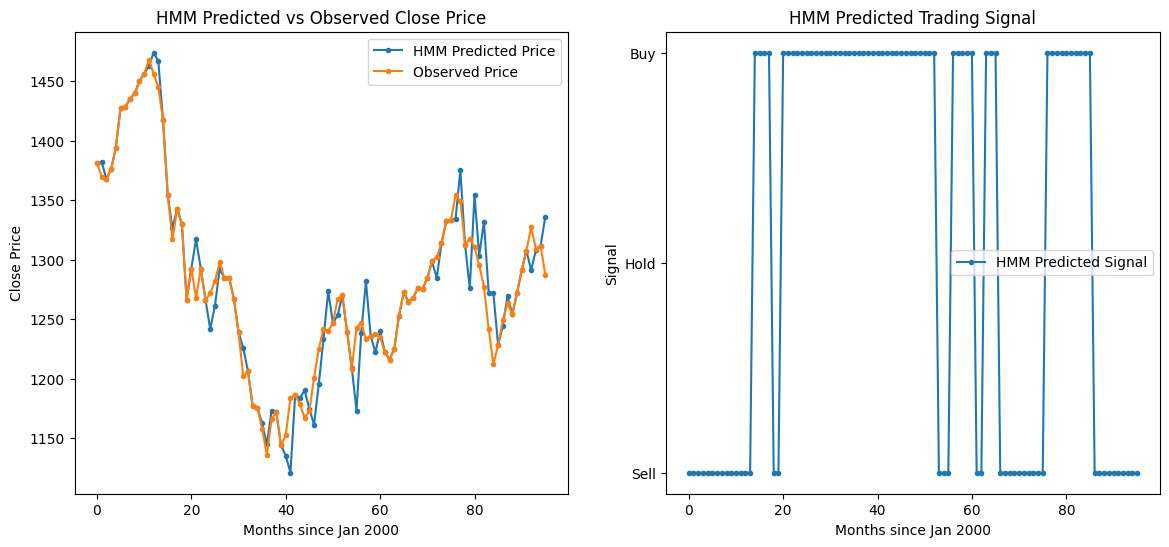

In [168]:
signals = GenerateSignals(obs_, expected_pct_changes, 0)
fig, ax = plt.subplots(figsize=(14, 6), ncols = 2)
hmm_price_array = np.array(hmm_price_orig)
ax[0].plot(hmm_price_array,marker='.', label = "HMM Predicted Price")
ax[0].plot(close,marker = '.', label= "Observed Price")
ax[0].set_ylabel("Close Price")
ax[0].set_xlabel("Months since Jan 2000")
ax[0].set_title("HMM Predicted vs Observed Close Price")
ax[0].legend()
ax[1].plot(signals,marker='.', label = "HMM Predicted Signal")
ax[1].set_ylabel("Signal")
ax[1].set_xlabel("Months since Jan 2000")
ax[1].set_yticks([-1, 0, 1], ['Sell', 'Hold', 'Buy'])
ax[1].set_title("HMM Predicted Trading Signal")
ax[1].legend()
plt.show()

In [169]:
def trading_strat(signals, close):
    """
    Simulate trading based on signals:
    - Buy = 1
    - Hold = 0
    - Sell = -1

    Owns either 0 or 1 unit of stock at any time

    Returns:
        values: portfolio value at each step
        positions: 0 or 1 stock held at each step
    """
    n = len(signals)
    values = np.zeros(n)      # Portfolio value
    positions = np.zeros(n)   # 0 or 1 stock held

    stocks_owned = 0
    cash = 0

    for i in range(n):
        if signals[i] == 1:  # Buy
            if stocks_owned == 0:
                stocks_owned = 1
                cash -= close[i]  # Spend money to buy
        elif signals[i] == -1:  # Sell
            if stocks_owned == 1:
                stocks_owned = 0
                cash += close[i]  # Receive cash from selling

        positions[i] = stocks_owned
        values[i] = cash + stocks_owned * close[i]  # Total portfolio value

    return values, positions

values, positions = trading_strat(signals, close)

In [170]:
def plot_trading_signals(close, signals, values, threshold):
    close = np.array(close)
    signals = np.array(signals)
    values = np.array(values)
    # Identify Buy/Sell indices
    buy_indices = np.where(signals == 1)[0]
    sell_indices = np.where(signals == -1)[0]

    plt.figure(figsize=(10,5))
    
    # Plot close price
    plt.plot(close, label='Close Price', color='blue')
    values = values + close[0]  # Normalize portfolio value to start at the same point as price
    # Plot portfolio value
    plt.plot(values, label='Portfolio Value', color='green', linestyle='--')
    
    # Plot buy/sell signals
    plt.scatter(buy_indices, close[buy_indices], marker='^', color='green', s=100, label='Buy Signal')
    plt.scatter(sell_indices, close[sell_indices], marker='v', color='red', s=100, label='Sell Signal')
    
    plt.title(f"HMM Trading Signals (Threshold: {threshold})")
    plt.xlabel("Time step")
    plt.ylabel("Price / Portfolio Value")
    plt.legend()
    plt.grid(True)
    plt.show()



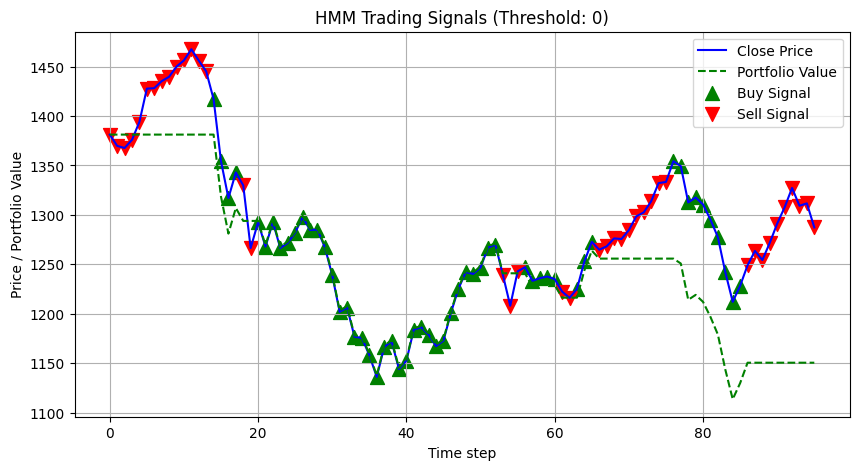

In [171]:
for t in [0]:
    signals = GenerateSignals(obs_, expected_pct_changes, threshold=t)
    values, positions = trading_strat(signals, close)
    plot_trading_signals(close, signals, values, threshold=t)